In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso,LogisticRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score, classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import opendatasets as od
from sklearn.naive_bayes import MultinomialNB,GaussianNB

In [2]:
! pip install pytorch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118


ERROR: Could not find a version that satisfies the requirement pytorch (from versions: none)
ERROR: No matching distribution found for pytorch


In [4]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout

In [5]:
od.download("https://www.kaggle.com/datasets/jayjoshi37/social-media-usage-vs-sleep-stress-and-productivity")

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username:Your Kaggle Key:Dataset URL: https://www.kaggle.com/datasets/jayjoshi37/social-media-usage-vs-sleep-stress-and-productivity


100%|██████████| 186k/186k [00:00<00:00, 468kB/s]

In [6]:
df = pd.read_csv("C:\\Users\\workstation\\OneDrive\\Music\\NTI\\social-media-usage-vs-sleep-stress-and-productivity\\social_media_sleep_stress_productivity_11000.csv", encoding='latin-1')

In [7]:
df.head()

,user_id,age,daily_screen_time_hours,social_media_hours,sleep_hours,exercise_minutes,study_work_hours,productivity_score,stress_level,platform
0,1,44,2.39,1.93,8.46,61,3.73,33.86,Low,YouTube
1,2,30,7.22,5.24,7.34,28,6.80,85.32,Low,YouTube
2,3,23,2.56,4.64,4.69,8,4.47,60.07,High,YouTube
3,4,36,8.75,4.89,5.05,53,9.53,36.46,Medium,LinkedIn
4,5,34,10.96,2.77,7.12,83,7.01,32.93,Medium,Instagram


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  11000 non-null  int64  
 1   age                      11000 non-null  int64  
 2   daily_screen_time_hours  11000 non-null  float64
 3   social_media_hours       11000 non-null  float64
 4   sleep_hours              11000 non-null  float64
 5   exercise_minutes         11000 non-null  int64  
 6   study_work_hours         11000 non-null  float64
 7   productivity_score       11000 non-null  float64
 8   stress_level             11000 non-null  object 
 9   platform                 11000 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 859.5+ KB


In [9]:
df['stress_level'].value_counts()

stress_level
Low       3715
Medium    3681
High      3604
Name: count, dtype: int64

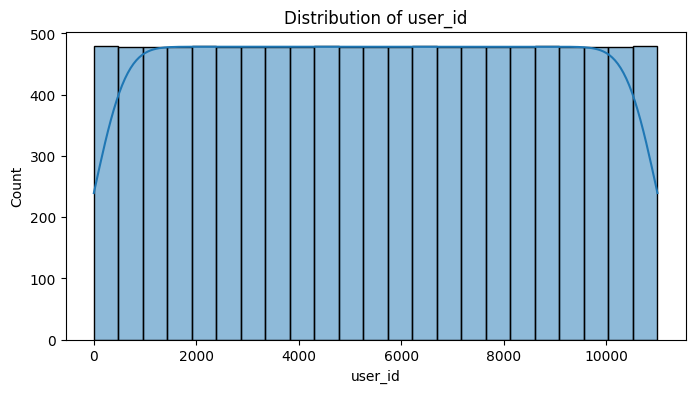

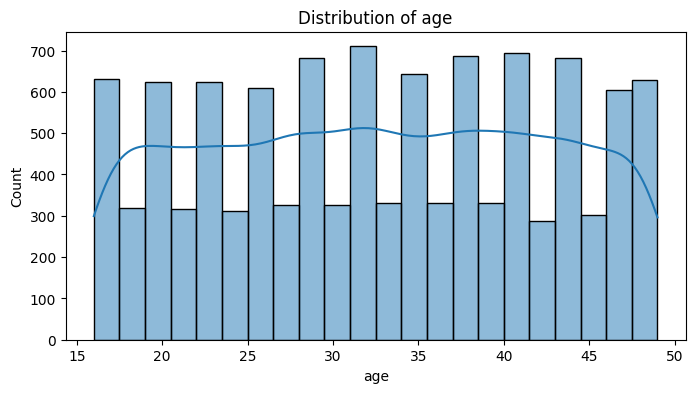

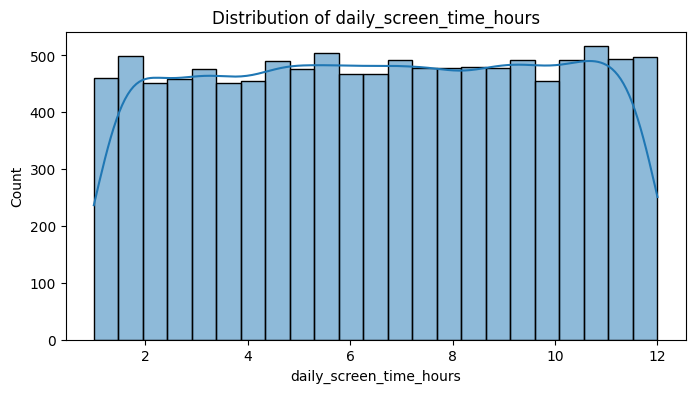

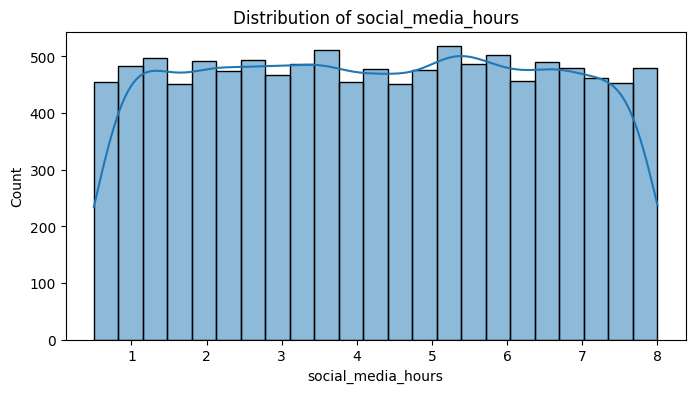

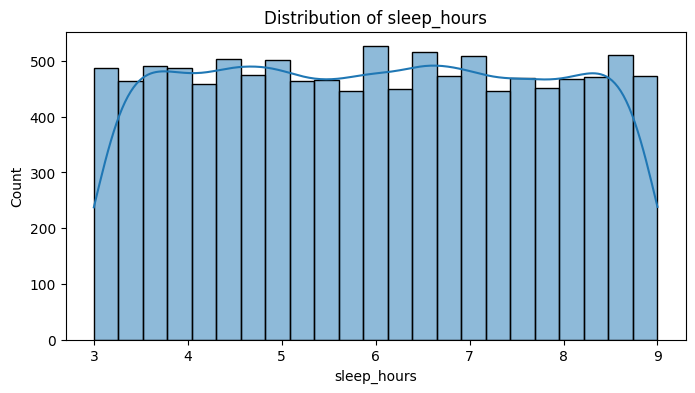

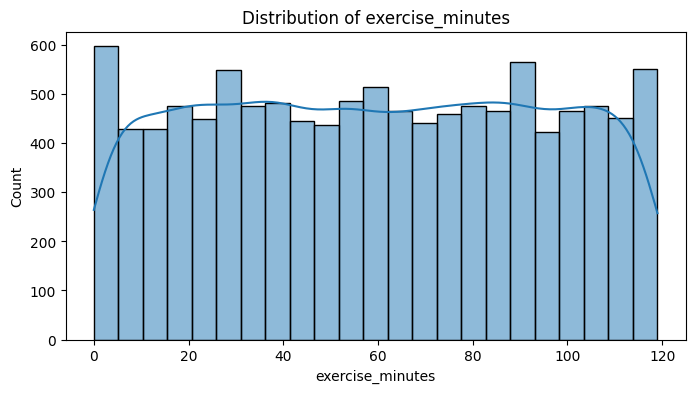

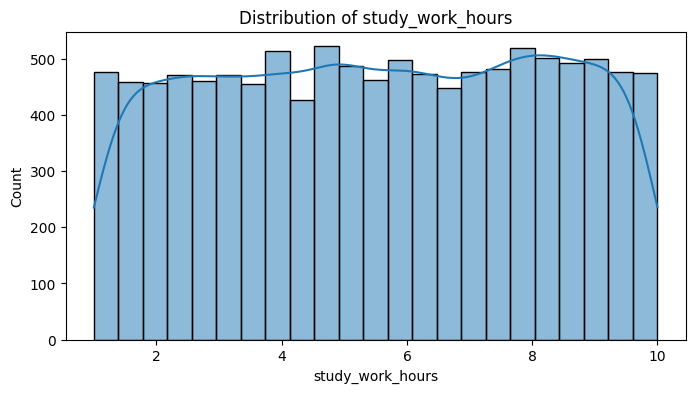

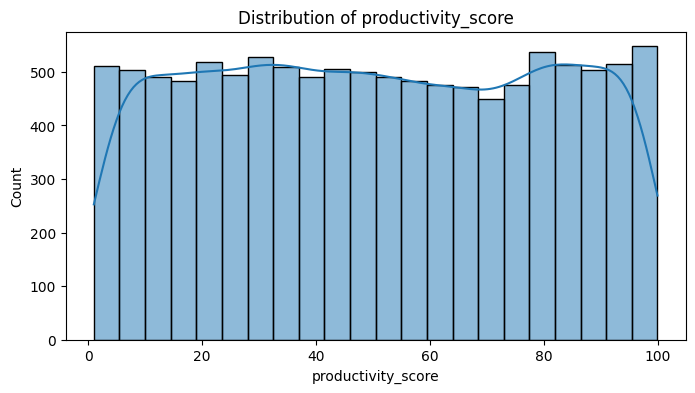

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()

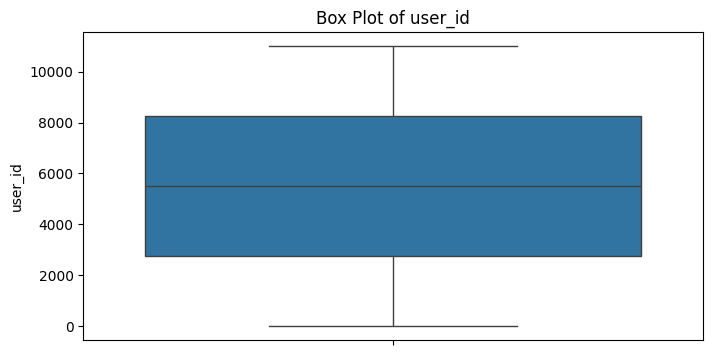

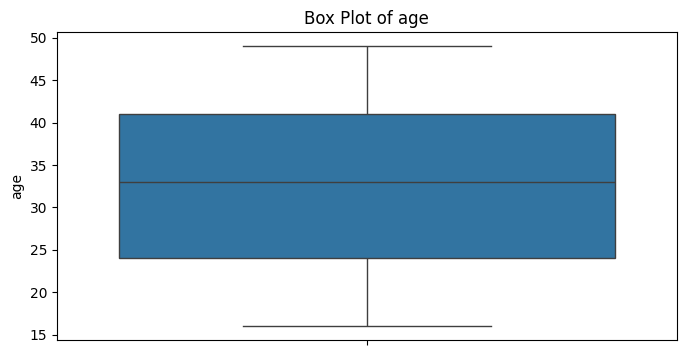

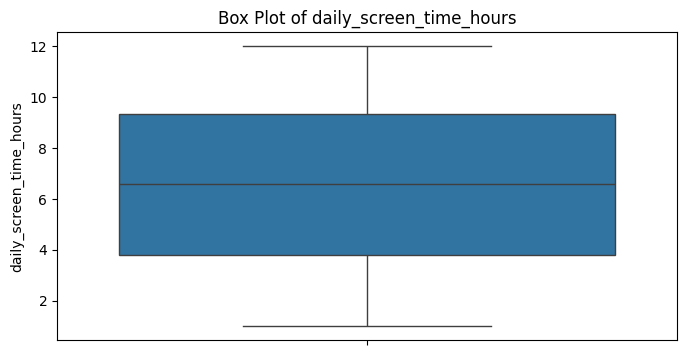

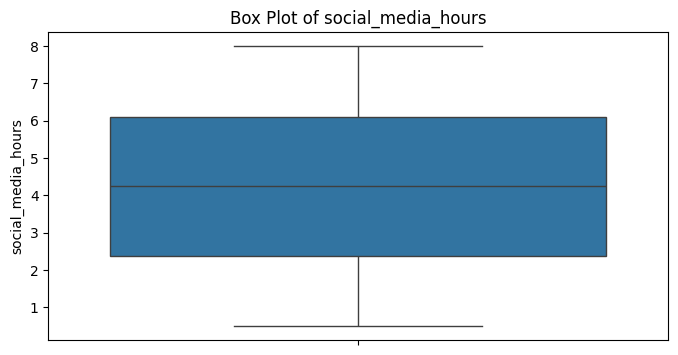

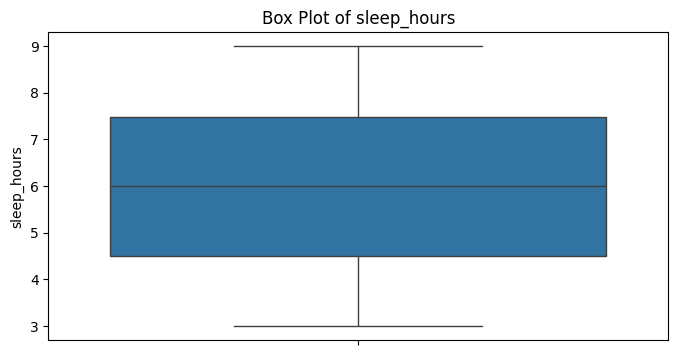

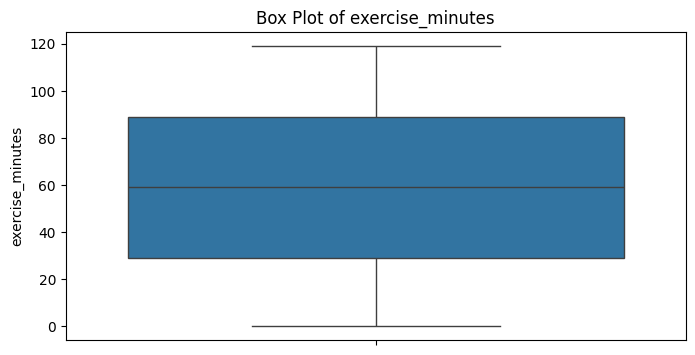

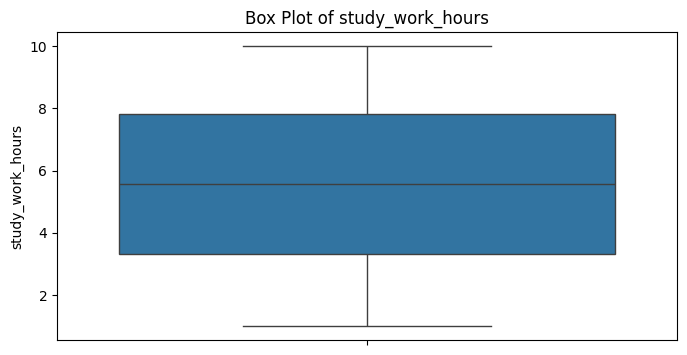

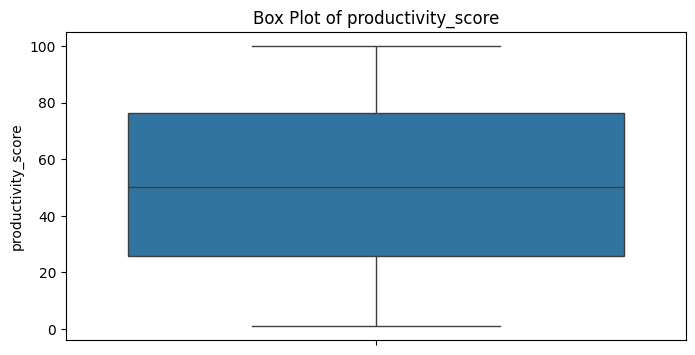

In [20]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.boxplot(df[col])
    plt.title(f'Box Plot of {col}')
    plt.show()

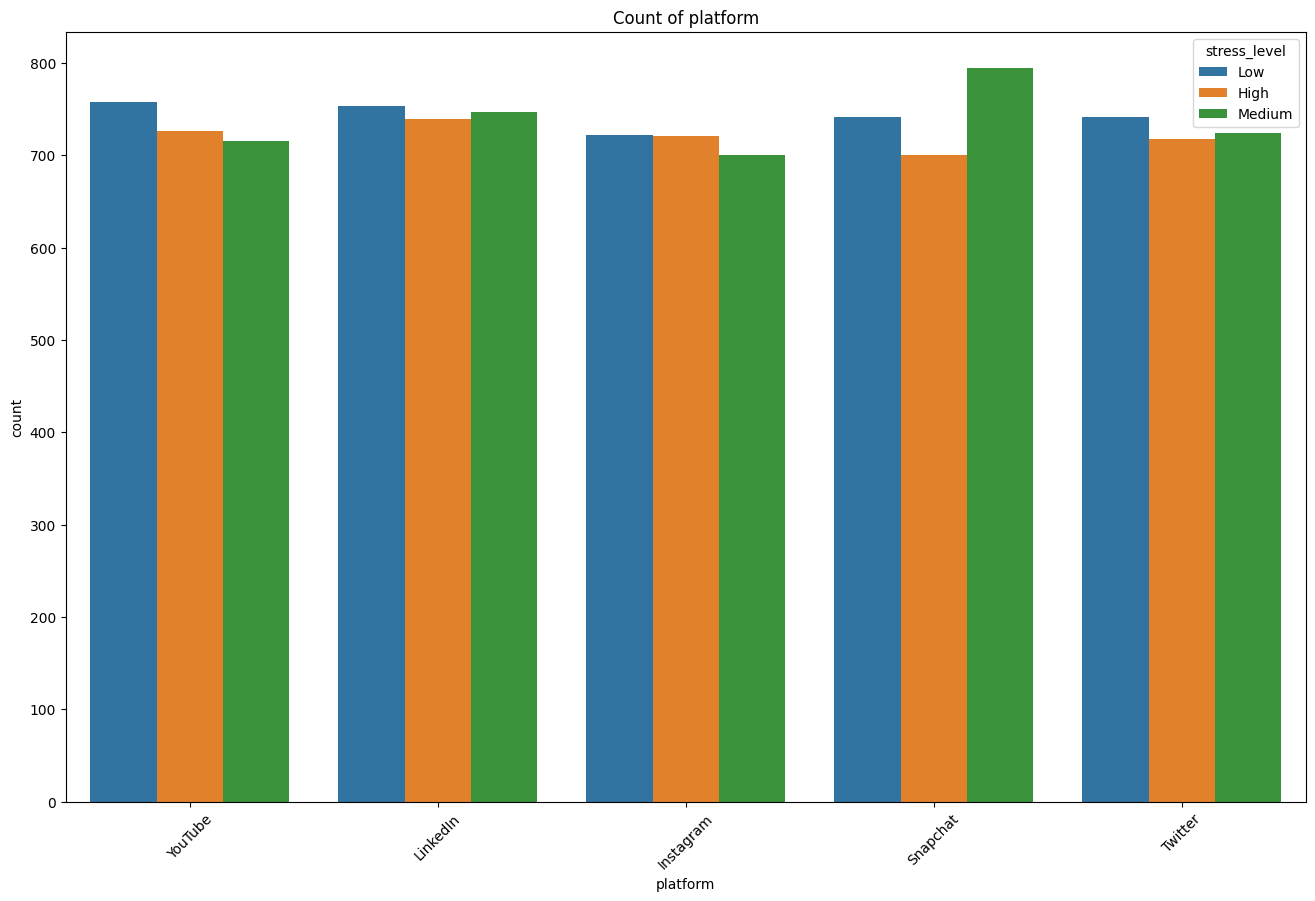

In [19]:
for col in categorical_cols:
    if col != 'stress_level':
        plt.figure(figsize=(16, 10))
        sns.countplot(data=df, x=col, hue='stress_level')
        plt.title(f'Count of {col}')
        plt.xticks(rotation=45)
        plt.show()

  

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11000 entries, 0 to 10999
Data columns (total 10 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   user_id                  11000 non-null  int64  
 1   age                      11000 non-null  int64  
 2   daily_screen_time_hours  11000 non-null  float64
 3   social_media_hours       11000 non-null  float64
 4   sleep_hours              11000 non-null  float64
 5   exercise_minutes         11000 non-null  int64  
 6   study_work_hours         11000 non-null  float64
 7   productivity_score       11000 non-null  float64
 8   stress_level             11000 non-null  object 
 9   platform                 11000 non-null  object 
dtypes: float64(5), int64(3), object(2)
memory usage: 859.5+ KB


In [ ]:
# Prepare a clean dataframe for the deep neural-network model
df_model = df.copy()

stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
df_model['stress_level'] = df_model['stress_level'].map(stress_mapping)

df_model.drop(columns=['user_id'], inplace=True)
df_model.dropna(subset=['stress_level'], inplace=True)
df_model['stress_level'] = df_model['stress_level'].astype('int32')


In [ ]:
# One-hot encode categorical columns and convert every feature to numeric values
df_model = pd.get_dummies(df_model, columns=['platform'], drop_first=True, dtype='float32')

for col in df_model.columns:
    if col != 'stress_level':
        df_model[col] = pd.to_numeric(df_model[col], errors='coerce')

df_model.dropna(inplace=True)


In [ ]:
df_model.info()
df_model['stress_level'].value_counts().sort_index()


In [ ]:
# Split features and target before scaling to avoid data leakage
x = df_model.drop('stress_level', axis=1).astype('float32')
y = df_model['stress_level'].astype('int32')

x_train, x_temp, y_train, y_temp = train_test_split(
    x,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

x_val, x_test, y_val, y_test = train_test_split(
    x_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train).astype('float32')
x_val_scaled = scaler.transform(x_val).astype('float32')
x_test_scaled = scaler.transform(x_test).astype('float32')

y_train = y_train.to_numpy(dtype='int32')
y_val = y_val.to_numpy(dtype='int32')
y_test = y_test.to_numpy(dtype='int32')

print(f'Train shape: {x_train_scaled.shape}')
print(f'Validation shape: {x_val_scaled.shape}')
print(f'Test shape: {x_test_scaled.shape}')


In [ ]:
# Build the deep neural-network classifier
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.callbacks import EarlyStopping

n_features = x_train_scaled.shape[1]
n_classes = y.nunique()

tf.keras.utils.set_random_seed(42)

model = Sequential([
    Input(shape=(n_features,)),
    Dense(128, activation='relu'),
    Dropout(0.30),
    Dense(64, activation='relu'),
    Dropout(0.20),
    Dense(32, activation='relu'),
    Dropout(0.10),
    Dense(n_classes, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


In [ ]:
# Train with a validation set and stop when validation loss stops improving
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True
)

history = model.fit(
    x_train_scaled,
    y_train,
    validation_data=(x_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1
)


In [ ]:
# Evaluate on the untouched test set
test_loss, test_accuracy = model.evaluate(x_test_scaled, y_test, verbose=0)
print(f'Test Loss: {test_loss:.4f}')
print(f'Test Accuracy: {test_accuracy:.4f}')


In [ ]:
# Make predictions and inspect class-level performance
class_names = ['Low', 'Medium', 'High']
y_pred_proba = model.predict(x_test_scaled)
y_pred_classes = np.argmax(y_pred_proba, axis=1)

print('Classification Report:')
print(classification_report(y_test, y_pred_classes, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_classes)
print('
Confusion Matrix:')
print(cm)


In [ ]:
# Plot training history
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
